In [1]:
import re
import os, json

# dedent : 여러줄 문자열을 코드상 보기 좋게 들여쓰기했을 때, 공통 들여쓰기를 제거하는 함수 (불필요한 앞쪽 공백 제거)
from textwrap import dedent
from pprint import pprint

import warnings

warnings.filterwarnings("ignore")

from dotenv import load_dotenv

load_dotenv()

True

### State Reducer
- 상태 업데이트를 관리하는 함수
- 그래프의 각 노드의 출력을 그래프의 전체 상태에 통합하는 방법을 정의
- 동작 방식 : 
    - 각 노드의 반환값은 해당 상태 키의 이전 값을 덮어쓰기 저장 (basic reducer)
    - 메시지 리스트 등에서 이전 상태에 새로운 값을 추가할 때 사용 (add reducer)
    - 중복 제거, 정렬 등 특수한 상태 관리를 하는 사용자 정의 리듀서 지원 (custom reducer)

(1) Reducer를 별도로 지정하지 않는 경우
- 기존 값을 덮어쓰는 방식으로 동작 (overwrite)

In [2]:
# import libraries
from typing import TypedDict, Annotated, List
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy
from IPython.display import Image, display

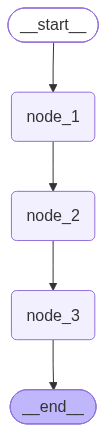

In [3]:

# state definition
class DocumentState(TypedDict):
    query: str
    documents: List[str]


# Node 1 : query update
def node_1(state: DocumentState) -> DocumentState:
    print("--Node 1 : query update--")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가
def node_2(state: DocumentState) -> DocumentState:
    print("--Node 2: 검색된 문서 추가--")
    documents = ["doc1.pdf", "doc2.pdf", "doc3.pdf"]
    return {"documents": documents}

# Node 3: 추가적인 문서 검색 결과 업데이트
def node_3(state: DocumentState) -> DocumentState:
    print("--Node 3: 추가적인 문서 검색 결과 업데이트--")
    documents = ["doc2.pdf", "doc4.pdf", "doc5.pdf"]
    return {"documents": documents}

# graph builder
builder = StateGraph(DocumentState)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()
# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 그래프 실행
initial_state = {"query": "애플파이 레시피 찾아줘.", "documents": None}

final_state = graph.invoke(initial_state)

print(f"최종 상태: {final_state}")


(2) Reducer 별조 지정하는 경우
- Annotated를 사용하여 지정한 reducer 작동 방식에 따라 기존 상태 정보를 업데이트
- 리스트를 병합하는 operator.add를 사용하면, activity_log를 누적하는 방식으로 노드를 구현

In [4]:
class ReducerDocumentState(TypedDict):
    query: str
    documents: Annotated[List[str], add]

# Node 1 : query update
def node_1(state: ReducerDocumentState) -> ReducerDocumentState:
    print("--Node 1 : query update--")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가
def node_2(state: ReducerDocumentState) -> ReducerDocumentState:
    print("--Node 2: 검색된 문서 추가--")
    documents = ["doc1.pdf", "doc2.pdf", "doc3.pdf"]
    return {"documents": documents}

# Node 3: 추가적인 문서 검색 결과 업데이트
def node_3(state: ReducerDocumentState) -> ReducerDocumentState:
    print("--Node 3: 추가적인 문서 검색 결과 업데이트--")
    documents = ["doc2.pdf", "doc4.pdf", "doc5.pdf"]
    return {"documents": documents}


# graph builder
builder = StateGraph(ReducerDocumentState)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)  

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()
        

In [ ]:
# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 그래프 실행
initial_state = {"query": "애플파이 레시피 찾아줘.", "documents": []}
initial_state = {"query": "애플파이 레시피 찾아줘."}

final_state = graph.invoke(initial_state)

print(f"최종 상태: {final_state}")

(3) Custom Reducer 
- 상태 업데이트가 기본적인 덮어쓰기나 병합만으로 해결되지 않을때 사용
- 중복제거, 최대/최소값 유지, 조건부 병합 등의 특정 비지니스 로직이 필요한 경우에 적용

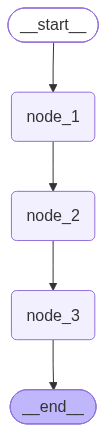

In [5]:
from typing import TypedDict, List, Annotated

# Custom Reducer : 중복된 문서 제거하되, 리스트 병합
def merge_unique_documents(left: List[str] | None, right: List[str] | None) -> List[str]:
    """Combine two lists of documents, removing duplicates."""
    if not left:
        left = []
    if not right: 
        right = []

    return list(set(left + right))

class CustomReducerDocumentState(TypedDict):
    query: str
    documents: Annotated[List[str], merge_unique_documents]

def node_1(state: CustomReducerDocumentState) -> CustomReducerDocumentState:
    print("--Node 1 : query update--")
    query = state["query"]
    return {"query": query}

def node_2(state: CustomReducerDocumentState) -> CustomReducerDocumentState:
    print("--Node 2: 검색된 문서 추가--")
    documents = ["doc1.pdf", "doc2.pdf", "doc3.pdf"]
    return {"documents": documents}

def node_3(state: CustomReducerDocumentState) -> CustomReducerDocumentState:
    print("--Node 3: 추가적인 문서 검색 결과 업데이트--")
    documents = ["doc2.pdf", "doc4.pdf", "doc5.pdf"]
    return {"documents": documents}

# graph builder
builder = StateGraph(CustomReducerDocumentState)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3") 
builder.add_edge("node_3", END)

graph = builder.compile()
        
# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
initial_state = {"query": "애플파이 레시피 찾아줘.", "documents": None}

final_state = graph.invoke(initial_state)

print(f"최종 상태: {final_state}")

### MessageGraph
- LangChain의 ChatModel을 위한 특수한 형태의 StateGraph
- Message 객체 목록(HumanMessage, AIMessage 등)을 입력으로 처리
- 목적: 대화 기록을 효과적으로 관리, 활용할 수 있음 (자연스러운 대화 흐름, 컨텍스트 활용 답변)

##### Message State Definition
1. 대화 기록을 그래프 상태에 메시지 목록으로 저장
2. Message 객체 목록을 저장하는 messages 키를 추가
3. 이 키에 리듀서 함수를 추가하여 메시지 업데이트를 관리

- operator.add: 새 메시지를 기존 목록에 단순히 추가


```
[방법 1]
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class MSGState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

[방법 2]
from langgraph.graph import MessagesState
from typing import List
from langchain_core.documents import Document

class MSGState(MessagesState):
    # messages 키는 기본 제공
    # 다른 키를 추가하고 싶은 경우 
    documents: List[Document]
    grad: float
    num_generation: int

```

In [10]:

from langgraph.graph import MessagesState
from typing import List
from langchain_core.documents import Document

class MSGState(MessagesState):
    # messages 키는 기본 제공, addMessagesReducer가 default로 적용된다.
    # 다른 키를 추가하고 싶은 경우 
    documents: List[Document]
    grade: float
    num_generation: int

(2) RAG Chain 
- initialize vector stor for menu search
- langchain Runnable

In [7]:
from pathlib import Path
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

PROJECT_ROOT = Path.cwd().parent
CHROMA_DIR = PROJECT_ROOT / "chroma_db"
DATA_DIR = PROJECT_ROOT / "data"

embeddings_model = OllamaEmbeddings(model="qwen3-embedding:0.6b") 

# 기존 Chroma 저장소 로드
menu_db = Chroma(
    embedding_function = embeddings_model,
    collection_name = "restaurant_menu",
    persist_directory = str(CHROMA_DIR),
    )

In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

# LLM model
gemini_llm = ChatGoogleGenerativeAI(model="gemini-3.8-flash", temperature=0)


# RAG Chain 
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

system = """
You are a helpful assistant. Use the following context to answer the user's question: 

[Context]
{context}
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "{question}")
])

# Menu Search
retriever = menu_db.as_retriever(
    search_kwargs = {
        "k": 2,
    }
)

# RAG Chain
# 1개의 쿼리를 입력 -> {"context": , "question": } 을 생성해서 prompt의 입력으로 전달 -> llm -> parser()
# RunnablePassthrough() : 입력을 그대로 전달 -> lamda x: x
# retriever | format_docs : format_docs는 일반 python 함수이지만, LCEL의 | 연산자가 일반 callable 함수를 만나면 
# 자동으로 RunnableLambda로 변환 해주기 때문에 별도의 처리가 필요 없음

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | gemini_llm
    | StrOutputParser()
)

query = "해산물 메뉴 추천해줘."
response = rag_chain.invoke(query)

print(response)


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


신선한 해산물이 듬뿍 들어간 **해산물 파스타**를 추천합니다!

* **메뉴명:** 해산물 파스타
* **가격:** ₩24,000
* **주요 식재료:** 링귀네 파스타, 새우, 홍합, 오징어, 토마토 소스
* **특징:** 알 덴테로 알맞게 삶은 링귀네 파스타에 새우, 홍합, 오징어 등 신선한 해산물을 아낌없이 올린 메뉴입니다. 토마토 소스의 산뜻한 산미와 해산물의 깊은 감칠맛이 잘 어우러지며, 마늘과 올리브 오일, 향긋한 파슬리가 풍미를 더해줍니다.


(3) Node

In [11]:
def retrieve_and_response(state: MSGState) -> MSGState:
    last_human_msg = state["messages"][-1]

    # HumanMessage 객체의 content 추출
    query = last_human_msg.content

    # Menu DB Search
    retrieved_docs = retriever.invoke(query)

    # Generate Response
    response = rag_chain.invoke(query)

    # 검색된 문서와 응답을 state에 저장
    return {
        "messages": [AIMessage(content = response)], # MessagesState 를 상속 -> addMessagesReducer 가 자동 적용
        "documents": retrieved_docs,
    }

### 답변 품질 평가 노드

In [12]:
from pydantic import BaseModel, Field

class GradeResponse(BaseModel):
    "Score for answer"
    score: float = Field(..., ge = 0, le = 1, description = "A score from 0 to 1, where 1 is the best score.")
    explanation: str = Field(..., description = "An explanation for the given score.")

def grade_response(state: MSGState) -> MSGState:
    messages = state["messages"]
    question = messages[-2].content 
    answer = messages[-1].content
    context = format_docs(state["documents"])

    grading_system = """
    you are an expert grader. Grade the following answer based on its relevance and accuracy to the question, considering the given context.
    Provide a score from 0 to 1, where 1 is perfect, along with an explanation.
    """

    grading_prompt = ChatPromptTemplate.from_messages([
        ("system", grading_system),
        ("human", "[Question]\n{question}\n\n[Answer]\n{answer}\n\n[Context]\n{context}\n\n[Grade]\n"),
    ])

    grading_chain = grading_prompt | gemini_llm.with_structured_output(schema = GradeResponse)

    grade_response = grading_chain.invoke({
        "question": question,
        "context": context,
        "answer": answer,
    })

    # 응답 횟수 제한을 위해 현재 횟수 측정
    num_generation = state.get('num_generation', 0)
    num_generation += 1

    return {"grade": grade_response.score, "num_generation": num_generation}
        


(4) edges

In [13]:
from typing import Literal

def retry_or_stop(state: MSGState) -> Literal["retrieve_and_response", "generate"]:
    print("---GRADING---")
    print("Grade Score: ", state["grade"])

    # num_generation >= 3, then "generate"
    if state["num_generation"] >= 3:
        return "generate"
    
    # num_generation < 3, and grade < 0.7 then "retrieve_and_response"
    if state["grade"] < 0.7:
        return "retrieve_and_response"
    
    # num_generation < 3, and grade >= 0.7 then "generate"
    return "generate"

    

(5) Graph

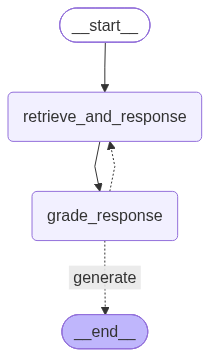

In [14]:
builder = StateGraph(MSGState)

builder.add_node("retrieve_and_response", retrieve_and_response)
builder.add_node("grade_response", grade_response)

builder.add_edge(START, "retrieve_and_response")
builder.add_edge("retrieve_and_response", "grade_response")
builder.add_conditional_edges(
    "grade_response",
    retry_or_stop,
    {"retrieve_and_response": "retrieve_and_response", "generate": END},
)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 그래프 실행
initial_state = {
    "messages": [HumanMessage(content = "해산물 메뉴 추천해줘.")]
}

final_state = graph.invoke(initial_state)

###  Gradio 챗봇

In [ ]:
import gradio as gr
from typing import List

# 질문 예시
example_questions = [
    "채식주의자를 위한 메뉴를 추천해주세요.",
    "오늘의 스페셜 메뉴는 무엇인가요?",
    "파스타에 어울리는 음료는 무엇인가요?"
]

# 대답 함수 정의
# Gradio ChatInterface는 fn이 기본적으로 두 개의 positional argument를 받는다고 기대함: 첫 번째는 현재 사용자 메시지, 두 번째는 이전 대화 기록.
def answer_invoke(message: str, history: List[dict]) -> str:
    try:
        # 채팅 기록을 AI에게 전달할 수 있는 형식으로 변환
        chat_history = []
        for msg in history:
            if msg["role"] == "user":
                chat_history.append(HumanMessage(content=msg["content"]))
            elif msg["role"] == "assistant":
                chat_history.append(AIMessage(content=msg["content"]))

        # 기존 채팅 기록에 사용자의 메시지를 추가 (최근 2개 대화만 사용)
        initial_state = {
            "messages": chat_history[-4:]+[HumanMessage(content=message)],  
        }

        # 메시지를 처리하고 최종 상태를 반환
        final_state = graph.invoke(initial_state)
        
        # 최종 상태에서 필요한 부분 반환 (예: 추천 메뉴 등)
        return final_state["messages"][-1].content
        
    except Exception as e:
        # 오류 발생 시 사용자에게 알리고 로그 기록
        print(f"Error occurred: {str(e)}")
        return "죄송합니다. 응답을 생성하는 동안 오류가 발생했습니다. 다시 시도해 주세요."


# Gradio 인터페이스 생성
demo = gr.ChatInterface(
    fn=answer_invoke,
    title="레스토랑 메뉴 AI 어시스턴트",
    description="메뉴 정보, 추천, 음식 관련 질문에 답변해 드립니다.",
    examples=example_questions,
)

# Gradio 앱 실행
demo.launch(theme=gr.themes.Soft())


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Error occurred: Server disconnected without sending a response.
---GRADING---
Grade Score:  1.0
